    horizon_k                     model      rmse       mae  ARCH_LM_stat  \
3           1  ARX + diurnal + seasonal  1.482128  0.955778    719.749465   
1           1             ARX + diurnal  1.482835  0.955935    716.597880   
2           1            ARX + seasonal  1.487441  0.948707    723.640807   
0           1                 ARX basic  1.488064  0.948477    720.872566   
7           2  ARX + diurnal + seasonal  2.169026  1.450117   1942.045481   
5           2             ARX + diurnal  2.170128  1.449230   1936.078889   
6           2            ARX + seasonal  2.181556  1.444084   1973.107676   
4           2                 ARX basic  2.182455  1.442701   1967.519487   
11          3  ARX + diurnal + seasonal  2.630454  1.799608   3560.537361   
9           3             ARX + diurnal  2.631061  1.795218   3548.617093   
10          3            ARX + seasonal  2.649943  1.794659   3613.372205   
8           3                 ARX basic  2.650208  1.788992   3602.352796   

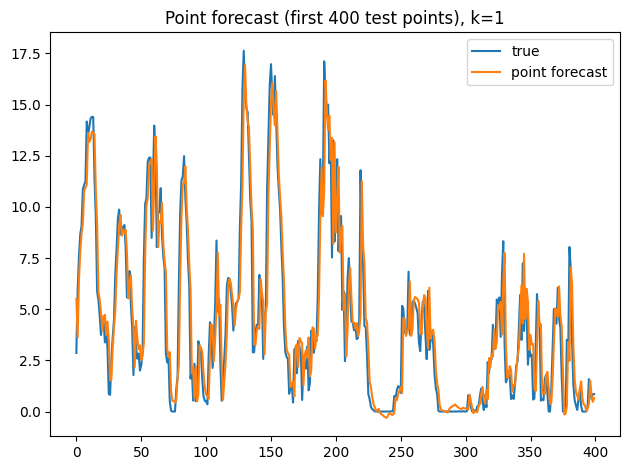

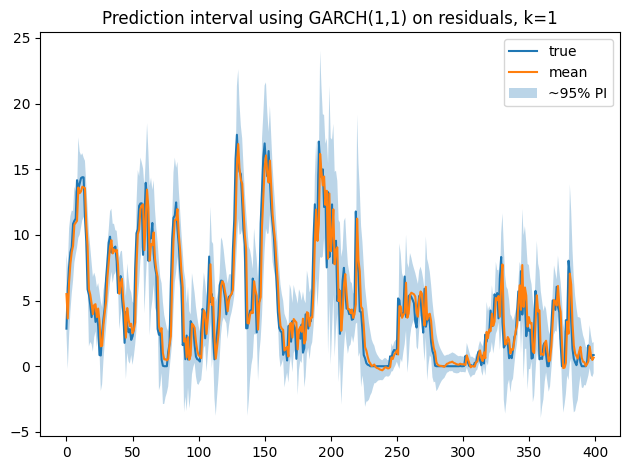


Empirical 95% PI coverage (k=1): 0.923


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.stats.diagnostic import het_arch

# Optional: GARCH fitting (may not be installed)
try:
    from arch import arch_model
    HAS_ARCH = True
except Exception:
    HAS_ARCH = False

PATH = "data/cex4WindDataInterpolated.csv"
df = pd.read_csv(PATH)
df["t"] = pd.to_datetime(df["t"], errors="coerce")
df = df.sort_values("t").reset_index(drop=True)

# ---------- Feature engineering ----------
df["hour"] = df["t"].dt.hour.astype(float)
df["sin_hour"] = np.sin(2*np.pi*df["hour"]/24.0)
df["cos_hour"] = np.cos(2*np.pi*df["hour"]/24.0)

# toy normalization to [0,1)
if "toy" in df.columns:
    toy = df["toy"].astype(float).copy()
    if toy.max() > 2:   # likely day-of-year like 1..365
        toy = toy / 365.0
    df["toy_norm"] = (toy % 1.0).astype(float)
else:
    df["toy_norm"] = (df["t"].dt.dayofyear / 365.0) % 1.0

df["sin_toy"] = np.sin(2*np.pi*df["toy_norm"])
df["cos_toy"] = np.cos(2*np.pi*df["toy_norm"])

def add_wd_features(df, wd_col):
    ang = (df[wd_col].astype(float) % 360.0) / 360.0 * 2*np.pi
    return np.sin(ang), np.cos(ang)

# ---------- Design matrix builder (direct, horizon k) ----------
def build_dataset(df, k, use_diurnal=True, use_seasonal=True):
    ws = f"Ws{k}"
    wd = f"Wd{k}"
    if ws not in df.columns or wd not in df.columns:
        raise ValueError(f"Missing {ws}/{wd}")

    sin_wd, cos_wd = add_wd_features(df, wd)

    y = df["p"].shift(-k)

    X = pd.DataFrame({
        "const": 1.0,
        "p_t": df["p"].astype(float),
        "Ws": df[ws].astype(float),
        "Ws2": (df[ws].astype(float))**2,
        "sin_wd": sin_wd,
        "cos_wd": cos_wd,
    })

    if use_diurnal:
        X["sin_hour"] = df["sin_hour"]
        X["cos_hour"] = df["cos_hour"]
    if use_seasonal:
        X["sin_toy"] = df["sin_toy"]
        X["cos_toy"] = df["cos_toy"]

    data = pd.concat([y.rename("y"), X], axis=1).dropna()
    return data

def ols_fit_predict(data, train_frac=0.8):
    y = data["y"].to_numpy()
    X = data.drop(columns=["y"]).to_numpy()
    names = data.drop(columns=["y"]).columns.tolist()

    n = len(y)
    split = int(n * train_frac)
    y_tr, X_tr = y[:split], X[:split]
    y_te, X_te = y[split:], X[split:]

    beta, *_ = np.linalg.lstsq(X_tr, y_tr, rcond=None)
    yhat = X_te @ beta
    resid = y_te - yhat

    rmse = float(np.sqrt(np.mean(resid**2)))
    mae = float(np.mean(np.abs(resid)))

    return {
        "beta": beta,
        "names": names,
        "y_test": y_te,
        "yhat": yhat,
        "resid": resid,
        "rmse": rmse,
        "mae": mae
    }

def arch_test(resid, nlags=24):
    lm_stat, lm_p, f_stat, f_p = het_arch(resid, nlags=nlags)
    return {"lm_stat": lm_stat, "lm_p": lm_p, "f_stat": f_stat, "f_p": f_p}

def fit_garch_on_resid(resid):
    if not HAS_ARCH:
        return None
    # Fit GARCH(1,1) with Student-t innovations on residuals
    am = arch_model(resid, mean="Zero", vol="GARCH", p=1, q=1, dist="t")
    res = am.fit(disp="off")
    return res

def prediction_interval(yhat, sigma, alpha=0.05):
    # normal approx; if you want t-quantile, use res.distribution for arch fit
    z = 1.96  # ~ N(0,1) 97.5%
    lo = yhat - z*sigma
    hi = yhat + z*sigma
    return lo, hi

# ---------- Run ablation over horizons ----------
settings = [
    ("ARX basic", False, False),
    ("ARX + diurnal", True, False),
    ("ARX + seasonal", False, True),
    ("ARX + diurnal + seasonal", True, True),
]

all_rows = []
stored = {}  # keep best model outputs for plotting

for k in [1,2,3]:
    for name, use_diurnal, use_seasonal in settings:
        data = build_dataset(df, k, use_diurnal=use_diurnal, use_seasonal=use_seasonal)
        out = ols_fit_predict(data)

        at = arch_test(out["resid"], nlags=24)

        row = {
            "horizon_k": k,
            "model": name,
            "rmse": out["rmse"],
            "mae": out["mae"],
            "ARCH_LM_stat": at["lm_stat"],
            "ARCH_LM_p": at["lm_p"],
        }
        all_rows.append(row)

        # store the most complete one for each k for later
        if name == "ARX + diurnal + seasonal":
            stored[k] = {"out": out, "arch_test": at}

results = pd.DataFrame(all_rows).sort_values(["horizon_k","rmse"])
print(results)

# ---------- Optional: fit GARCH on residuals of the full mean model ----------
if HAS_ARCH:
    for k in [1,2,3]:
        out = stored[k]["out"]
        garch_res = fit_garch_on_resid(out["resid"])
        stored[k]["garch"] = garch_res
        print(f"\n===== GARCH fit summary (k={k}) =====")
        print(garch_res.summary())
else:
    print("\n[Info] `arch` package not available here. GARCH fitting skipped.")

# ---------- Example plot: prediction interval for k=1 (if GARCH available) ----------
k = 1
out = stored[k]["out"]
y_te = out["y_test"]
yhat = out["yhat"]

plt.figure()
plt.plot(y_te[:400], label="true")
plt.plot(yhat[:400], label="point forecast")
plt.title("Point forecast (first 400 test points), k=1")
plt.legend()
plt.tight_layout()
plt.show()

if HAS_ARCH:
    garch_res = stored[k]["garch"]
    # 1-step-ahead conditional sigma for the residual series (aligned to test segment)
    # simplest: use in-sample conditional volatility estimates
    sigma = garch_res.conditional_volatility
    # sigma corresponds to the residual series you fit; its length equals len(resid)
    sigma_te = sigma  # already residual-of-test length because we fit on resid (test only)
    lo, hi = prediction_interval(yhat, sigma_te)

    plt.figure()
    plt.plot(y_te[:400], label="true")
    plt.plot(yhat[:400], label="mean")
    plt.fill_between(np.arange(400), lo[:400], hi[:400], alpha=0.3, label="~95% PI")
    plt.title("Prediction interval using GARCH(1,1) on residuals, k=1")
    plt.legend()
    plt.tight_layout()
    plt.show()

    # coverage on full test residual series
    inside = (y_te >= lo) & (y_te <= hi)
    coverage = inside.mean()
    print(f"\nEmpirical 95% PI coverage (k=1): {coverage:.3f}")
